# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

**Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (Kaggle, UCI ML Repository, Open Data) atau data primer yang Anda kumpulkan sendiri.


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

# Dataset California Housing
from sklearn.datasets import fetch_california_housing

# Untuk preprocessing
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [2]:
# Load dataset
california = fetch_california_housing(as_frame=True)

df = california.frame
df['MedHouseVal'] = california.target

# Simpan dataset ke format .csv
df.to_csv('california_housing.csv', index=False)

# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

**A. Overview Data**

In [3]:
df.shape

(20640, 9)

In [4]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [6]:
# Statistik deskriptif
print("STATISTIK DESKRIPTIF")
df.describe()

STATISTIK DESKRIPTIF


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [7]:
# Menampilkan isi kolom MedHouseVal dengan unik
df["MedHouseVal"].unique()

array([4.526, 3.585, 3.521, ..., 4.258, 2.007, 0.47 ])

In [8]:
# Cek keseimbangan nilai MedHouseVal
df["MedHouseVal"].value_counts()

,count
MedHouseVal,
5.00001,965
1.37500,122
1.62500,117
1.12500,103
1.87500,93
...,...
3.52500,1
4.65000,1
4.57500,1


In [9]:
# Karna nilai diatas 5 terlalu tinggi maka perlu diberi batasan 4.9
df_clean = df[df["MedHouseVal"] < 4.9]

**B. Visualisasi Data**

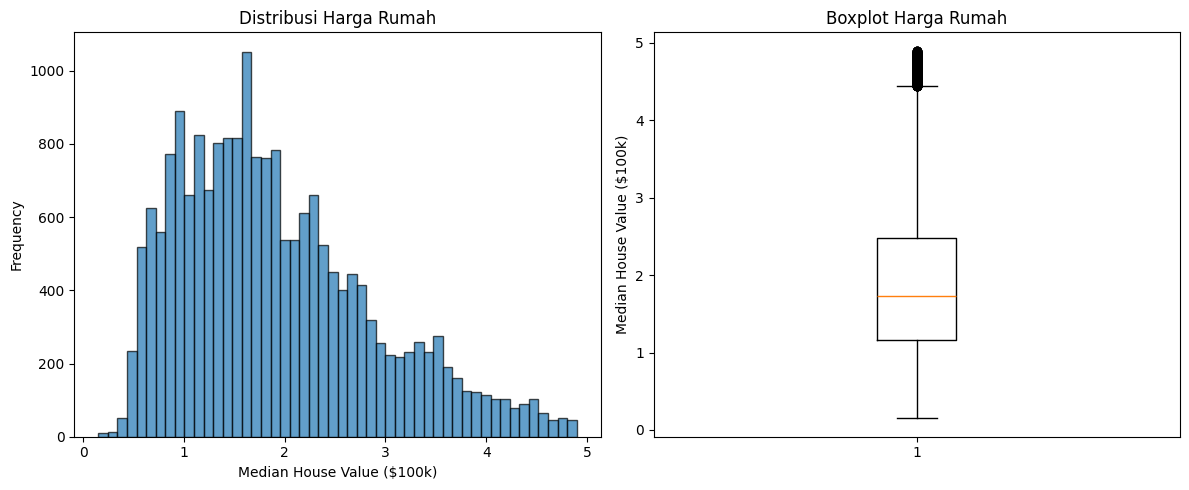

In [10]:
# Distribusi target variable
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(df_clean['MedHouseVal'], bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('Median House Value ($100k)')
plt.ylabel('Frequency')
plt.title('Distribusi Harga Rumah')

plt.subplot(1, 2, 2)
plt.boxplot(df_clean['MedHouseVal'])
plt.ylabel('Median House Value ($100k)')
plt.title('Boxplot Harga Rumah')

plt.tight_layout()
plt.show()

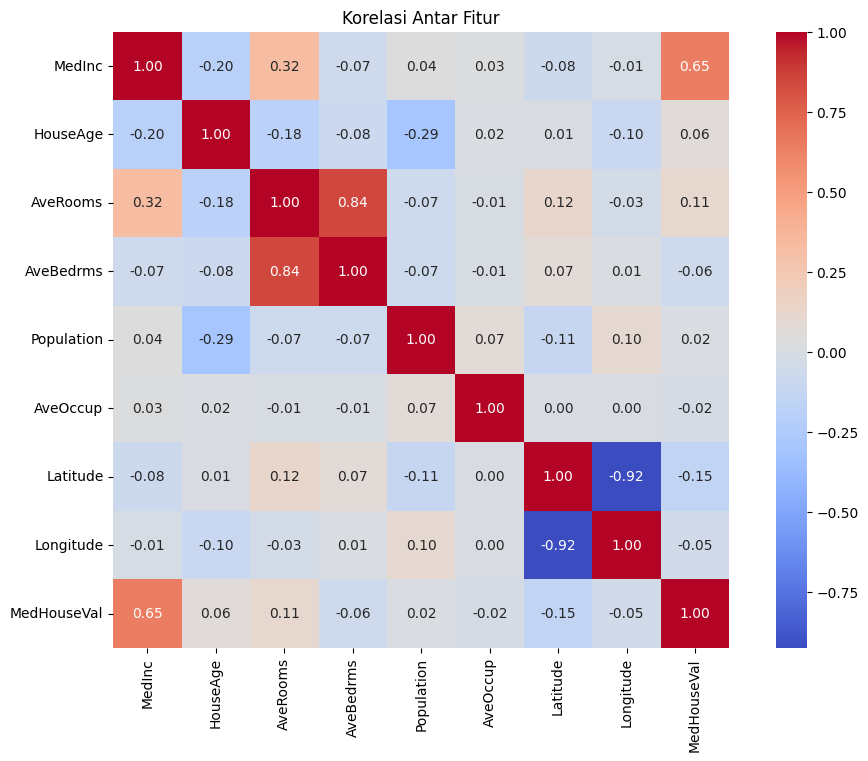

In [11]:
# Korelasi antar fitur
plt.figure(figsize=(12, 8))
correlation_matrix = df_clean.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', square=True)
plt.title('Korelasi Antar Fitur')
plt.show()

In [12]:
# Melihat fitur yang paling berkorelasi dengan target (MedHouseVal)
corr_with_target = correlation_matrix['MedHouseVal'].sort_values(ascending=False)
print("KORELASI DENGAN TARGET (MedHouseVal)")
print("="*36)
print(corr_with_target)

KORELASI DENGAN TARGET (MedHouseVal)
MedHouseVal    1.000000
MedInc         0.645032
AveRooms       0.109828
HouseAge       0.063295
Population     0.015378
AveOccup      -0.021035
Longitude     -0.046240
AveBedrms     -0.061872
Latitude      -0.149483
Name: MedHouseVal, dtype: float64


# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

**1. Menangani data kosong (Missing Values)**

In [20]:
print(f"Missing values: {df.isnull().sum().sum()}")
print(f"Jumlah data: {len(df)}")

Missing values: 0
Jumlah data: 20640


**2. Menangani data duplikat**

In [21]:
# Cek dan hapus duplikat
duplicates = df.duplicated().sum()
print(f"   Jumlah data duplikat: {duplicates}")
if duplicates > 0:
    df = df.drop_duplicates()
    print(f"{duplicates} data duplikat dihapus")

   Jumlah data duplikat: 0


**3. Penangan Outlier**

In [23]:
# Feature Engineering: Membuat rasio BedroomsPerRoom
df['BedroomsPerRoom'] = df['AveBedrms'] / df['AveRooms']

# Pembersihan Outlier dengan Metode IQR untuk fitur yang krusial
df_clean = df.copy()
features_for_iqr = ['BedroomsPerRoom', 'MedInc', 'MedHouseVal']

for col in features_for_iqr:
    if col in df_clean.columns:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Eksekusi penghapusan baris di luar batas normal
        df_clean = df_clean[(df_clean[col] >= lower_bound) & (df_clean[col] <= upper_bound)]

print(f"✅ Selesai ditangani. Baris data berkurang dari {df.shape[0]} menjadi {df_clean.shape[0]}.")

✅ Selesai ditangani. Baris data berkurang dari 20640 menjadi 18693.


**4. Bining (Pengelompokkan Data)**

In [24]:
df_clean['IncomeCategory'] = pd.qcut(df_clean['MedInc'], q=3, labels=['Low_Income', 'Medium_Income', 'High_Income'])
print("Kolom 'IncomeCategory' berhasil dibuat.")
print(df_clean[['MedInc', 'IncomeCategory']].head())

Kolom 'IncomeCategory' berhasil dibuat.
   MedInc IncomeCategory
2  7.2574    High_Income
3  5.6431    High_Income
4  3.8462  Medium_Income
5  4.0368  Medium_Income
6  3.6591  Medium_Income


**5. Encoding data kategorikal**

In [25]:
income_mapping = {'Low_Income': 0, 'Medium_Income': 1, 'High_Income': 2}
df_clean['IncomeCategory_Encoded'] = df_clean['IncomeCategory'].map(income_mapping)
print("Proses Encoding data kategorikal selesai.")
print(df_clean[['IncomeCategory', 'IncomeCategory_Encoded']].head())

Proses Encoding data kategorikal selesai.
  IncomeCategory IncomeCategory_Encoded
2    High_Income                      2
3    High_Income                      2
4  Medium_Income                      1
5  Medium_Income                      1
6  Medium_Income                      1


**6. Split Dataset**

In [26]:
X = df_clean.drop(columns=['MedHouseVal', 'IncomeCategory', 'PriceCategory'], errors='ignore')
y = df_clean['MedHouseVal']

# Split data (95% Train, 5% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.05, random_state=42, shuffle=True)

print("Dimensi setelah Split:")
print(f"   - X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"   - X_test: {X_test.shape}, y_test: {y_test.shape}")

Dimensi setelah Split:
   - X_train: (17758, 10), y_train: (17758,)
   - X_test: (935, 10), y_test: (935,)


**7. Normalisasi / Standarisasi Fitur**

In [27]:
numerical_columns = X.columns.tolist()

numeric_transformer = StandardScaler()

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_transformer, numerical_columns)
    ])

Kesesuaian Kolom Train & Test: True


In [28]:
# Menyusun Pipeline
pipeline = Pipeline(steps=[("preprocessor", preprocessor)])

# Transformasi Fitur
X_train_clean = pipeline.fit_transform(X_train)
X_test_clean = pipeline.transform(X_test)

# Kembalikan ke DataFrame Pandas
data_train_clean = pd.DataFrame(X_train_clean, columns=numerical_columns)
data_test_clean = pd.DataFrame(X_test_clean, columns=numerical_columns)

# Masukkan kembali targetnya
data_train_clean["MedHouseVal"] = y_train.reset_index(drop=True)
data_test_clean["MedHouseVal"] = y_test.reset_index(drop=True)

print("   ✅ Seluruh fitur numerik dan hasil encode sukses distandarisasi!")

   ✅ Seluruh fitur numerik dan hasil encode sukses distandarisasi!


**8. Ekspor to CSV**

In [29]:
# Ekspor hasil pemrosesan akhir ke file CSV tanpa menyertakan indeks baris
data_train_clean.to_csv("train_processed.csv", index=False)
data_test_clean.to_csv("test_processed.csv", index=False)

print("✅ File 'train_processed.csv' dan 'test_processed.csv' berhasil diekspor.")

✅ File 'train_processed.csv' dan 'test_processed.csv' berhasil diekspor.


In [30]:
# Simpan model dengan ekstensi .pkl
joblib.dump(pipeline, "model/preprocessing_pipeline.pkl")
print("✅ Objek pipeline berhasil disimpan di: 'model/preprocessing_pipeline.pkl'")

✅ Objek pipeline berhasil disimpan di: 'model/preprocessing_pipeline.pkl'
